# Seminar 1: Linear Regression
## 1. Part I: Data preparation & analysis
Create a module that processes the data. The main operations your module must do are:

In [ ]:
import pandas as pd
import numpy as np
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1. Loading the dataset from the .txt file and storing the data in a structured manner

The .txt file is loaded as a .csv and the columns are renamed to make it easier to read.


In [ ]:
column_names = [
    "num_stas",                # Number of STAs
    "load_mbps",               # Load
    "size_x_m",                # Size(x)
    "size_y_m",                # Size(y)
    "area_m2",                 # Area
    "contention_window",       # Contention window
    "channel_width_mhz",       # Channel width
    "packet_size_bits",        # Packet size
    "max_rssi_dbm",            # Max RSSI
    "avg_rssi_dbm",            # Avg. RSSI
    "min_rssi_dbm",            # Min RSSI
    "avg_prob_failure",        # Avg. Probability of failure
    "throughput_bps",          # Throughput
    "avg_delay_sec",           # Average delay
    "total_airtime_sec",       # Total airtime
    "proportional_airtime"     # Proportional airtime
]

In [ ]:
labels = [
    "avg_prob_failure",        # Avg. Probability of failure
    "throughput_bps",          # Throughput
    "avg_delay_sec",           # Average delay
    "total_airtime_sec",       # Total airtime
    "proportional_airtime"     # Proportional airtime
]

In [ ]:
def load_data(filepath):
    df = pd.read_csv(filepath, sep=" ", header=None, names=column_names)
    return df

In [ ]:
df = load_data("dataset_Seminar1.txt")

### 1.2. Displaying statistics about each feature (mean, standard deviation)

The data is explored with different statistical functions provided by the `describe()` function, to understand the values ​​in which the parameters move.


In [ ]:
print(df.describe())

            num_stas     load_mbps       size_x_m       size_y_m  \
count  100000.000000  1.000000e+05  100000.000000  100000.000000   
mean       21.446170  2.140292e+07      20.562940      20.479640   
std        11.554365  1.852042e+07      11.545206      11.540626   
min         2.000000  5.000000e+05       1.000000       1.000000   
25%        11.000000  7.250000e+06      11.000000      11.000000   
50%        21.000000  1.600000e+07      21.000000      20.000000   
75%        31.000000  3.000000e+07      31.000000      30.000000   
max        41.000000  8.200000e+07      40.000000      40.000000   

             area_m2  contention_window  channel_width_mhz  packet_size_bits  \
count  100000.000000      100000.000000      100000.000000     100000.000000   
mean      421.270350         227.043920          75.106000       7997.580000   
std       360.344349         323.350855          53.704279       2825.532513   
min         1.000000           3.000000          20.000000       40

### 1.3. Plotting relevant figures to visualize how data is distributed

In this section, we analyze how variables relate to each other. Our goal is to identify the most relevant parameters (features) that influence `throughput`. To do this, we use a correlation matrix, which allows us to detect variables that exhibit a strong correlation (positive or negative) with network performance.

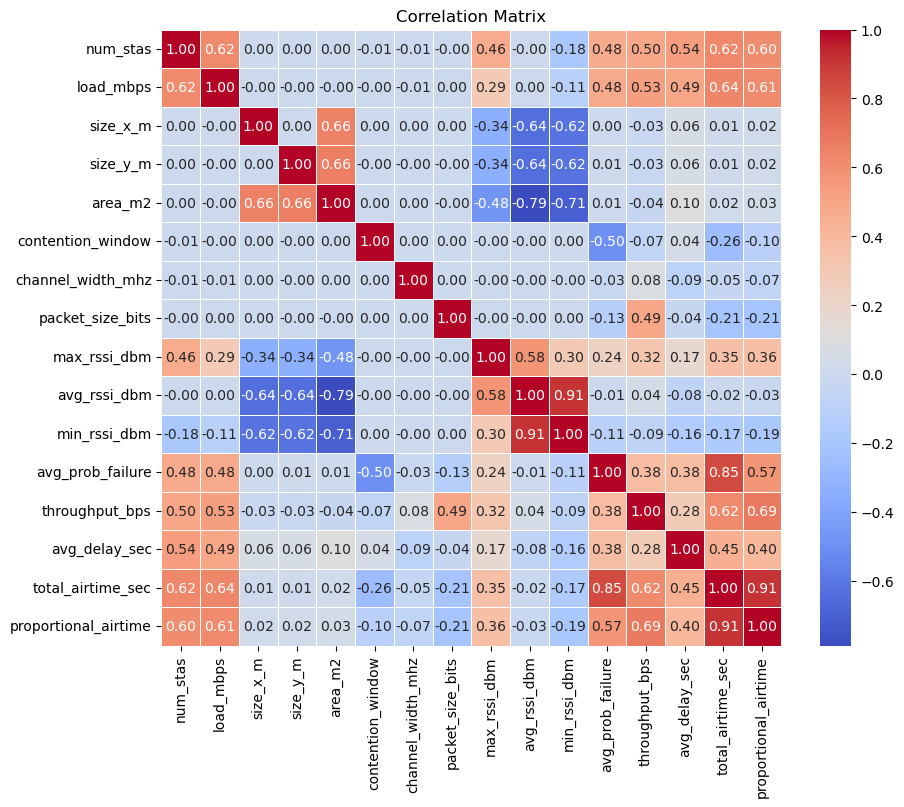

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
correlated = df.columns[(corr_matrix["throughput_bps"].abs() >= 0.3) & (corr_matrix["throughput_bps"].abs() < 1.0)]
relevant_params = correlated[~correlated.isin(labels)] # Features that are not on the labels
print(relevant_params.tolist())

['num_stas', 'load_mbps', 'packet_size_bits', 'max_rssi_dbm']


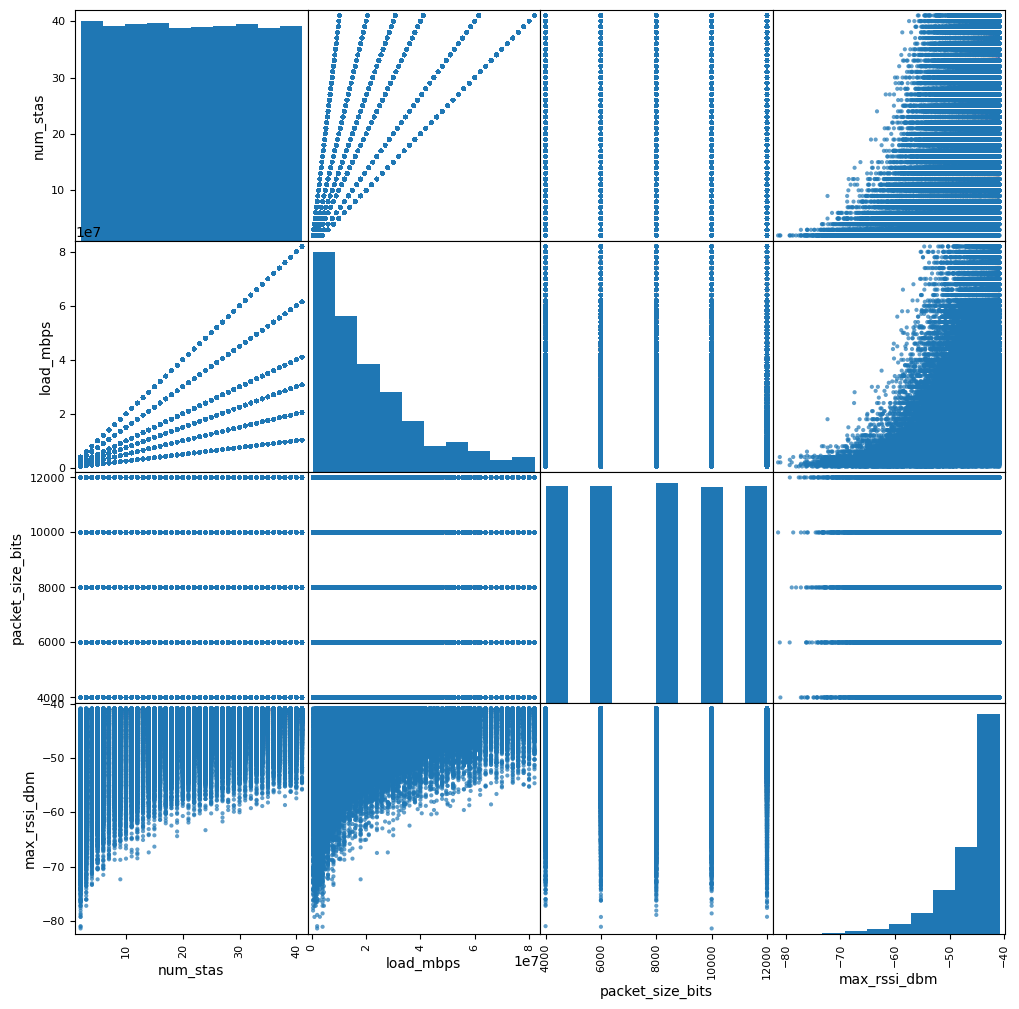

In [ ]:
scatter_matrix(df[relevant_params], figsize=(12, 12), diagonal='hist', alpha=0.7)
plt.show()

### 1.4. Processing the data (e.g., cleaning, normalization, categorical, etc.) and prepare it to be used by an ML model

<span style="color:blue">

- **Cleaning**: The data do not have missing values, so we do not perform any data imputation operations.
- **Normalation**: We use max-min scaling to normalize the values ​​to a range between 0 and 1. This will help us maintain the shape of the data distribution.
- **Categorization**: Since we have little information about the data and their values, we avoid categorizing them in the first place.
</span>

In [ ]:
print(df.isnull().sum())

num_stas                0
load_mbps               0
size_x_m                0
size_y_m                0
area_m2                 0
contention_window       0
channel_width_mhz       0
packet_size_bits        0
max_rssi_dbm            0
avg_rssi_dbm            0
min_rssi_dbm            0
avg_prob_failure        0
throughput_bps          0
avg_delay_sec           0
total_airtime_sec       0
proportional_airtime    0
dtype: int64


$$x_{\text{norm}} = \dfrac{x-x_{\min}}{x_{\max}-x_{\min}}$$

In [ ]:
X_norm = (df[relevant_params] - df[relevant_params].min()) / (df[relevant_params].max() - df[relevant_params].min())
y_norm = (df['throughput_bps'] - df['throughput_bps'].min()) / (df['throughput_bps'].max() - df['throughput_bps'].min())

In [ ]:
print(X_norm.describe())
print(y_norm.describe())

            num_stas      load_mbps  packet_size_bits   max_rssi_dbm
count  100000.000000  100000.000000     100000.000000  100000.000000
mean        0.498620       0.256478          0.499698       0.875496
std         0.296266       0.227244          0.353192       0.133203
min         0.000000       0.000000          0.000000       0.000000
25%         0.230769       0.082822          0.250000       0.820730
50%         0.487179       0.190184          0.500000       0.919898
75%         0.743590       0.361963          0.750000       0.974712
max         1.000000       1.000000          1.000000       1.000000
count    100000.000000
mean          0.416586
std           0.224115
min           0.000000
25%           0.257097
50%           0.389363
75%           0.584598
max           1.000000
Name: throughput_bps, dtype: float64


### 1.5. Splitting the data into different partitions to be used for training (e.g., 80%) and testing (e.g., 20%)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)

(80000, 4)


## 2. Part II: Model implementation
Create a module that trains and evaluate a linear regression model. The main operations
your module must do are:

### 2.1. Fitting the data into an ML model (in this case, a multi-variable linear regression), i.e., estimating the coefficients of the model

The model is trained using multivariate linear regression. The coefficients obtained indicate the impact of each independent variable on the model's prediction. The intercept represents the prediction when all independent variables (x1, x2, ...) are zero.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(model.coef_)
print(model.intercept_)

[0.16741266 0.34777408 0.31222409 0.20150724]
-0.0884056334930215


### 2.2. Evaluating the performance of the model using a given error function

We evaluated the model using four error metrics. We generally want the MSE, RMSE, and MAE values, which range between 0 and 1, to be as low as possible. This is in contrast to the coefficient of determination (R2), where values ​​close to 1 indicate a good fit.

The resulting values ​​are relatively low, suggesting that the model has an acceptable average error, and an R2 of 57.23%, indicating that it explains more than half of the data.

- MSE (Mean Squared Error)
- RMSE (Square MSE)
- MAE (Mean Absolute Error)
- R2 Score (Coef. Determination)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model evaluation:")
print(f" - MSE:  {mse:.4f}")
print(f" - RMSE: {rmse:.4f}")
print(f" - MAE:  {mae:.4f}")
print(f" - R²:   {r2:.4f}")

Model evaluation:
 - MSE:  0.0216
 - RMSE: 0.1468
 - MAE:  0.1178
 - R²:   0.5723


### 2.3. Plotting the results visually (e.g., training loss, test accuracy)

In the first graph, we can see how the model's prediction (red line) aligns with the actual data values.
The second graph allows us to identify whether the model has bias. A symmetrical distribution around zero is desirable in these cases.

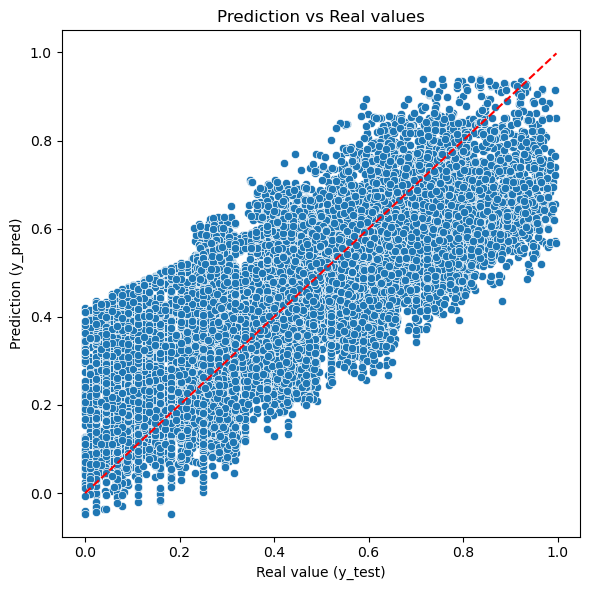

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title("Prediction vs Real values")
plt.xlabel("Real value (y_test)")
plt.ylabel("Prediction (y_pred)")
plt.tight_layout()
plt.show()

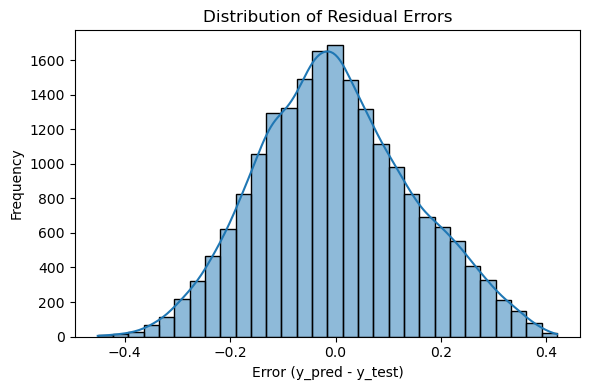

In [ ]:
residuals = y_pred - y_test

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution of Residual Errors")
plt.xlabel("Error (y_pred - y_test)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()